# 04 — LightGBM: Tuned and Calibrated
Can a gradient-boosted model beat the logistic regression baseline (test ROC-AUC 0.671, PR-AUC 0.219)?

Uses the **same patient-grouped test set** saved in Step 3.

In [ ]:
from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve

PROC, FIG, RES, MOD = Path("data/processed"), Path("figures"), Path("results"), Path("models")
MOD.mkdir(exist_ok=True)

df = pd.read_parquet(PROC / "model_table.parquet")
test_patients = set(pd.read_parquet(PROC / "test_patients.parquet")["patient_nbr"])
is_test = df["patient_nbr"].isin(test_patients)

y, groups = df["readmit_30"], df["patient_nbr"]
X = df.drop(columns=["readmit_30", "patient_nbr"])
X_trainfull, y_trainfull, g_trainfull = X[~is_test], y[~is_test], groups[~is_test]
X_test, y_test = X[is_test], y[is_test]
print(f"Train: {len(X_trainfull):,}  Test: {len(X_test):,}")

Train: 79,567  Test: 19,773


## 1. Hold out a calibration set (also grouped by patient)
The model is tuned and trained on 80% of the training data; the other 20% is used only to calibrate its probabilities.

**Sigmoid (Platt) calibration** is used: it is smooth, so it never outputs exactly 0% or 100% and does not create ties between patients.

In [ ]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=7)
fit_idx, cal_idx = next(gss.split(X_trainfull, y_trainfull, g_trainfull))
X_fit, y_fit, g_fit = X_trainfull.iloc[fit_idx], y_trainfull.iloc[fit_idx], g_trainfull.iloc[fit_idx]
X_cal, y_cal = X_trainfull.iloc[cal_idx], y_trainfull.iloc[cal_idx]
print(f"Fit: {len(X_fit):,}  Calibration: {len(X_cal):,}")

Fit: 63,562  Calibration: 16,005


## 2. Hyperparameter search
Randomised search over 20 settings, 5-fold CV grouped by patient, optimising PR-AUC.
Takes a few minutes.

In [ ]:
base = LGBMClassifier(n_estimators=500, learning_rate=0.03, random_state=42, verbose=-1)
param_dist = {
    "num_leaves":        [15, 31, 63],
    "min_child_samples": [20, 50, 100, 200],
    "max_depth":         [-1, 5, 8],
    "subsample":         [0.7, 0.85, 1.0],
    "subsample_freq":    [1],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "reg_lambda":        [0, 1, 5, 10],
}
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
search = RandomizedSearchCV(base, param_dist, n_iter=20, scoring="average_precision",
                            cv=cv, random_state=42, n_jobs=-1, verbose=1)
search.fit(X_fit, y_fit, groups=g_fit)

print(f"Best CV PR-AUC: {search.best_score_:.3f}")
search.best_params_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV PR-AUC: 0.225


{'subsample_freq': 1,
 'subsample': 0.85,
 'reg_lambda': 1,
 'num_leaves': 15,
 'min_child_samples': 20,
 'max_depth': 8,
 'colsample_bytree': 0.8}

## 3. Calibrate the probabilities

In [ ]:
best = search.best_estimator_
calibrated = CalibratedClassifierCV(FrozenEstimator(best), method="sigmoid")
calibrated.fit(X_cal, y_cal)

p_raw = best.predict_proba(X_test)[:, 1]
p_cal = calibrated.predict_proba(X_test)[:, 1]
print(f"Mean predicted risk  raw {p_raw.mean():.3f}  calibrated {p_cal.mean():.3f}  actual {y_test.mean():.3f}")

Mean predicted risk  raw 0.113  calibrated 0.114  actual 0.113


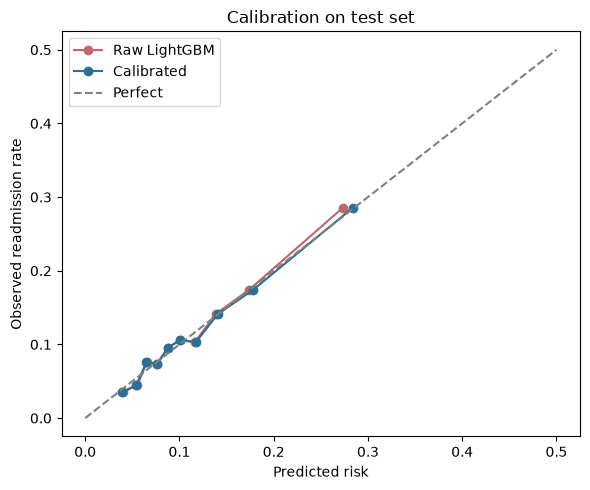

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for p, label, color in [(p_raw, "Raw LightGBM", "#c1666b"), (p_cal, "Calibrated", "#2a6f97")]:
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=label, color=color)
ax.plot([0, 0.5], [0, 0.5], "--", color="grey", label="Perfect")
ax.set(xlabel="Predicted risk", ylabel="Observed readmission rate", title="Calibration on test set")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "04_calibration.png", dpi=150)
plt.show()

## 4. Test-set results vs the baseline

In [ ]:
def evaluate(p, name):
    k = int(0.10 * len(p))
    top = np.argsort(p)[::-1][:k]
    return {"model": name,
            "test_roc_auc": round(roc_auc_score(y_test, p), 4),
            "test_pr_auc": round(average_precision_score(y_test, p), 4),
            "test_brier": round(brier_score_loss(y_test, p), 4),
            "test_precision_top10": round(float(y_test.iloc[top].mean()), 4),
            "test_recall_top10": round(float(y_test.iloc[top].sum() / y_test.sum()), 4)}

baseline = json.loads((RES / "03_baseline_metrics.json").read_text())
lgbm = evaluate(p_cal, "lightgbm_calibrated")
lgbm["cv_pr_auc"] = round(search.best_score_, 4)

cols = ["test_roc_auc", "test_pr_auc", "test_precision_top10", "test_recall_top10"]
comparison = pd.DataFrame([{k: m[k] for k in ["model"] + cols} for m in (baseline, lgbm)]).set_index("model")
comparison

,test_roc_auc,test_pr_auc,test_precision_top10,test_recall_top10
model,,,,
logistic_regression,0.6714,0.2191,0.2559,0.2255
lightgbm_calibrated,0.6816,0.2417,0.2858,0.2518


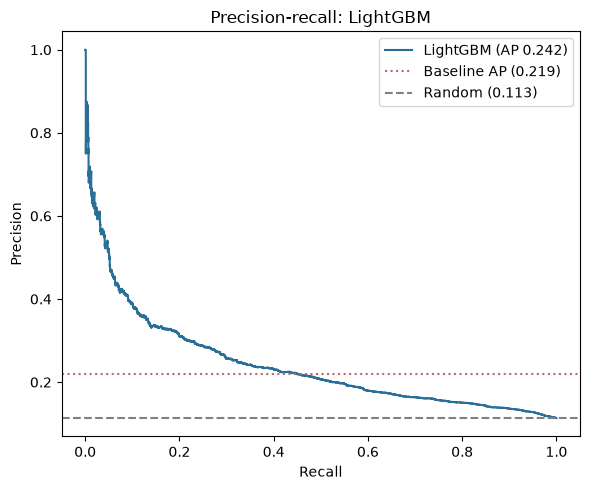

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
prec, rec, _ = precision_recall_curve(y_test, p_cal)
ax.plot(rec, prec, color="#2a6f97", label=f"LightGBM (AP {lgbm['test_pr_auc']:.3f})")
ax.axhline(baseline["test_pr_auc"], ls=":", color="#c1666b", label=f"Baseline AP ({baseline['test_pr_auc']:.3f})")
ax.axhline(y_test.mean(), ls="--", color="grey", label=f"Random ({y_test.mean():.3f})")
ax.set(xlabel="Recall", ylabel="Precision", title="Precision-recall: LightGBM")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "04_pr_curve.png", dpi=150)
plt.show()

## 5. Save the model, test predictions and metrics

In [ ]:
joblib.dump(calibrated, MOD / "lgbm_calibrated.joblib")
pd.DataFrame({"patient_nbr": groups[is_test].values, "y_true": y_test.values, "p_risk": p_cal}) \
  .to_parquet(PROC / "test_predictions.parquet", index=False)
(RES / "04_lightgbm_metrics.json").write_text(json.dumps({**lgbm, "best_params": search.best_params_}, indent=2))
print("Saved model, predictions and metrics")

Saved model, predictions and metrics


## 6. Summary
- **Best parameters:** 15 leaves, max depth 8, min 20 samples per leaf, 85% row and 80% column sampling, L2 = 1. That is a small, regularised model, which fits a noisy target.
- **Test ROC-AUC / PR-AUC vs baseline:** 0.682 / 0.242, against 0.671 / 0.219. PR-AUC improves by about 10%, and ROC-AUC sits within the 0.64–0.70 range published for this dataset. The ceiling comes from the data (no labs, vitals or notes), not the algorithm.
- **Top 10% riskiest patients vs baseline:** precision is 28.6% (vs 25.6%) and recall 25.2% (vs 22.6%). For the same follow-up workload, LightGBM catches about 12% more readmissions.
- **Calibration:** sigmoid (Platt) calibration was used. Isotonic was tried first, but it produced 100% risk scores and tied patients, which hurt ranking. The calibrated model sits on the diagonal (mean prediction 0.114, actual 0.113), so predicted risks can be read as real probabilities.